# Analyze XY optimization results

This notebook reads the best XY optimization results from the top-level
`results_XY/` directory and plots the optimal squeezing parameter `xi`
as a function of the number of XY layers for different `Rb` and
`Omega/Delta` values.

The optimization uses gate sequences

```text
layers_1:  XY_echo
layers_2:  XY_echo, Rx, XY_echo
layers_3:  XY_echo, Rx, XY_echo, Rx, XY_echo
...
```

Expected directory structure:

```text
results_XY/
└── 4x4/
    ├── Rb_1p5/
    │   ├── OmegaDelta_1_2/
    │   │   ├── single_pulse_min_time.npy
    │   │   ├── layers_1/
    │   │   │   └── summary.npz
    │   │   ├── layers_2/
    │   │   │   └── summary.npz
    │   │   └── ...
    │   ├── OmegaDelta_1_3/
    │   └── ...
    ├── Rb_2/
    └── Rb_2p5/
```

The preferred result format is `summary.npz`, containing `best_fun`
and `best_x`. Older JSON files of the form
`{"parameters": [...], "xi": ...}` are also supported.


In [31]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def dB(x):

    return 10 * np.log10(x)

## Locate the result directory

Run the notebook from the `VarOpt_MultiBody` project root. If the notebook
is stored or launched elsewhere, change `PROJECT_ROOT` below.


In [32]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "data" / "optimization_results" / "opt_XY"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Could not find results directory: {RESULTS_DIR}\n"
        "Set PROJECT_ROOT to the VarOpt_MultiBody project directory."
    )


Project root: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising
Results directory: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_XY


## Read all XY optimization results

For each `layers_*` directory, the notebook first looks for `summary.npz`.
If that file is absent, it falls back to older JSON optimization-result files
and keeps the entry with the smallest `xi`.

The single-`XY_echo` minimum time is also read from each
`OmegaDelta_*` directory when available.


In [33]:
def parse_rb(name):
    # Rb_1p5 -> 1.5, Rb_2 -> 2.0
    value = name.removeprefix("Rb_").replace("p", ".")
    return float(value)


def parse_omega_delta(name):
    # OmegaDelta_1_2 -> numerator=1, denominator=2, ratio=0.5
    match = re.fullmatch(
        r"OmegaDelta_(\d+)_(\d+)",
        name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse Omega/Delta folder name: {name}"
        )

    numerator = int(match.group(1))
    denominator = int(match.group(2))

    return (
        numerator,
        denominator,
        numerator / denominator,
    )


def parse_layer(name):
    match = re.fullmatch(
        r"layers_(\d+)",
        name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse layer folder name: {name}"
        )

    return int(match.group(1))


def xy_gate_sequence(n_layers):
    """
    Return the gate labels corresponding to the optimized parameter vector.

    Examples
    --------
    1 -> ["XY_echo"]
    2 -> ["XY_echo", "Rx", "XY_echo"]
    3 -> ["XY_echo", "Rx", "XY_echo", "Rx", "XY_echo"]
    """
    sequence = []

    for layer in range(n_layers):
        if layer > 0:
            sequence.append("Rx")

        sequence.append("XY_echo")

    return sequence


def read_best_result(layer_dir):
    """
    Read the best optimization result from a layer directory.

    Preferred format
    ----------------
    summary.npz

    Fallback format
    ---------------
    Older JSON optimization-result files.
    """

    summary_file = (
        layer_dir
        / "summary.npz"
    )

    if summary_file.exists():

        with np.load(
            summary_file
        ) as data:

            xi = float(
                data["best_fun"]
            )

            parameters = np.asarray(
                data["best_x"],
                dtype=float,
            )

            single_pulse_min_time = (
                float(data["single_pulse_min_time"])
                if "single_pulse_min_time" in data
                else np.nan
            )

            ub_XY = (
                float(data["ub_XY"])
                if "ub_XY" in data
                else np.nan
            )

        return {
            "xi": xi,
            "parameters": parameters,
            "file": summary_file,
            "source": "summary",
            "single_pulse_min_time": single_pulse_min_time,
            "ub_XY": ub_XY,
        }


    # --------------------------------------------------------
    # Old format: JSON files
    # --------------------------------------------------------

    json_files = [
        p
        for p in layer_dir.glob("*.json")
        if not p.name.endswith(".lock")
    ]

    if not json_files:
        return None

    records = []

    for path in json_files:

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            data = json.load(f)

        if (
            "xi" not in data
            or "parameters" not in data
        ):
            continue

        records.append(
            (
                float(data["xi"]),
                np.asarray(
                    data["parameters"],
                    dtype=float,
                ),
                path,
            )
        )

    if not records:
        return None

    xi, parameters, path = min(
        records,
        key=lambda x: x[0],
    )

    return {
        "xi": xi,
        "parameters": parameters,
        "file": path,
        "source": "json",
        "single_pulse_min_time": np.nan,
        "ub_XY": np.nan,
    }


# ============================================================
# Read all optimization results
# ============================================================

rows = []

for geometry_dir in sorted(
    RESULTS_DIR.iterdir()
):

    if not geometry_dir.is_dir():
        continue

    geometry = geometry_dir.name

    for rb_dir in sorted(
        geometry_dir.glob("Rb_*")
    ):

        if not rb_dir.is_dir():
            continue

        rb = parse_rb(
            rb_dir.name
        )

        for omega_dir in sorted(
            rb_dir.glob("OmegaDelta_*")
        ):

            if not omega_dir.is_dir():
                continue

            (
                num,
                den,
                omega_over_delta,
            ) = parse_omega_delta(
                omega_dir.name
            )

            cache_file = (
                omega_dir
                / "single_pulse_min_time.npy"
            )

            cached_single_pulse_min_time = (
                float(np.load(cache_file))
                if cache_file.exists()
                else np.nan
            )

            for layer_dir in sorted(
                omega_dir.glob("layers_*")
            ):

                if not layer_dir.is_dir():
                    continue

                n_layers = parse_layer(
                    layer_dir.name
                )

                best = read_best_result(
                    layer_dir
                )

                if best is None:
                    continue

                sequence = xy_gate_sequence(
                    n_layers
                )

                parameters = best["parameters"]

                if len(parameters) != len(sequence):
                    print(
                        "WARNING: parameter-count mismatch:",
                        layer_dir,
                        f"{len(parameters)=}",
                        f"{len(sequence)=}",
                    )

                single_pulse_min_time = (
                    best["single_pulse_min_time"]
                    if np.isfinite(best["single_pulse_min_time"])
                    else cached_single_pulse_min_time
                )

                rows.append({
                    "geometry": geometry,
                    "Rb": rb,
                    "omega_num": num,
                    "omega_den": den,
                    "Omega_over_Delta": omega_over_delta,
                    "Omega_over_Delta_label": f"{num}/{den}",
                    "layers": n_layers,
                    "xi": best["xi"],
                    "parameters": parameters,
                    "sequence": sequence,
                    "single_pulse_min_time": single_pulse_min_time,
                    "ub_XY": best["ub_XY"],
                    "file": str(best["file"]),
                    "source": best["source"],
                })


# ============================================================
# Build dataframe
# ============================================================

df = pd.DataFrame(
    rows
)

if df.empty:
    raise RuntimeError(
        f"No optimization results were found below {RESULTS_DIR}"
    )

df = df.sort_values(
    [
        "geometry",
        "Rb",
        "Omega_over_Delta",
        "layers",
    ]
).reset_index(
    drop=True
)

print(
    f"Loaded {len(df)} optimized layer results."
)

df.head()


Loaded 43 optimized layer results.


,geometry,Rb,omega_num,omega_den,Omega_over_Delta,Omega_over_Delta_label,layers,xi,parameters,sequence,single_pulse_min_time,ub_XY,file,source
0,4x4,1.5,1,10,0.1,1/10,1,0.585912,[72052.91524997303],[XY_echo],72047.985732,144095.971465,/Users/raka3858/PycharmProjects/PythonProject/...,summary
1,4x4,1.5,1,10,0.1,1/10,2,0.999944,"[2.000027755982899, 3.141592653589793, 2.00002...","[XY_echo, Rx, XY_echo]",1.000014,2.000028,/Users/raka3858/PycharmProjects/PythonProject/...,summary
2,4x4,1.5,1,10,0.1,1/10,3,0.999917,"[2.000027755982899, 3.141592653589793, 2.00002...","[XY_echo, Rx, XY_echo, Rx, XY_echo]",1.000014,2.000028,/Users/raka3858/PycharmProjects/PythonProject/...,summary
3,4x4,1.5,1,10,0.1,1/10,4,0.442772,"[28476.343974961914, -2.517647674845621, 92810...","[XY_echo, Rx, XY_echo, Rx, XY_echo, Rx, XY_echo]",72047.985732,NaN,/Users/raka3858/PycharmProjects/PythonProject/...,json
4,4x4,1.5,1,10,0.1,1/10,5,0.440592,"[28761.893549353186, 0.6285616110597315, 99069...","[XY_echo, Rx, XY_echo, Rx, XY_echo, Rx, XY_ech...",72047.985732,NaN,/Users/raka3858/PycharmProjects/PythonProject/...,json


## Compact table of optimal values

`single_pulse_min_time` is the characteristic first-minimum time obtained
from a single `XY_echo` pulse for that particular `Rb` and `Omega/Delta`.


In [34]:
display_cols = [
    "geometry",
    "Rb",
    "Omega_over_Delta_label",
    "layers",
    "xi",
    "single_pulse_min_time",
    "source",
]

df[display_cols]


,geometry,Rb,Omega_over_Delta_label,layers,xi,single_pulse_min_time,source
0,4x4,1.5,1/10,1,0.585912,72047.985732,summary
1,4x4,1.5,1/10,2,0.999944,1.000014,summary
2,4x4,1.5,1/10,3,0.999917,1.000014,summary
3,4x4,1.5,1/10,4,0.442772,72047.985732,json
4,4x4,1.5,1/10,5,0.440592,72047.985732,json
5,4x4,1.5,1/7,1,0.586706,18129.269370,summary
6,4x4,1.5,1/7,2,0.462868,18129.269370,json
7,4x4,1.5,1/7,3,0.440568,18129.269370,json
8,4x4,1.5,1/7,4,0.434589,18129.269370,json
9,4x4,1.5,1/7,5,0.455711,18129.269370,json


## Plot 1: one figure per $R_b$, lines for different $\Omega/\Delta$


In [35]:
print("Best squeezing found:")

best_row = df.loc[
    df["xi"].idxmin()
]

print(
    f"geometry={best_row['geometry']}, "
    f"Rb={best_row['Rb']:g}, "
    f"Omega/Delta={best_row['Omega_over_Delta_label']}, "
    f"layers={int(best_row['layers'])}, "
    f"xi={best_row['xi']:.8g}, "
    f"xi^2={dB(best_row['xi'] ** 2):.3f} dB"
)


Best squeezing found:
geometry=4x4, Rb=2, Omega/Delta=1/2, layers=5, xi=0.40893075, xi^2=-7.767 dB


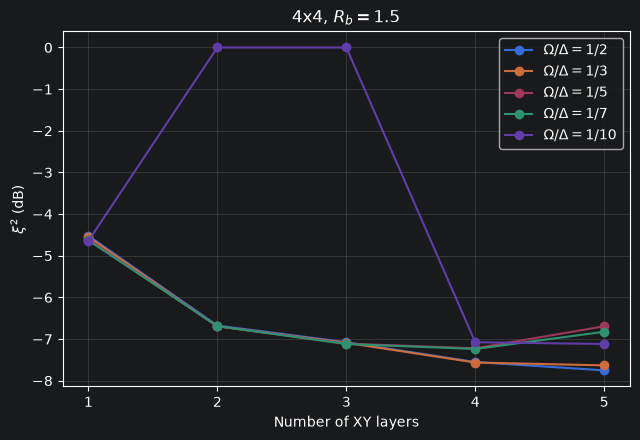

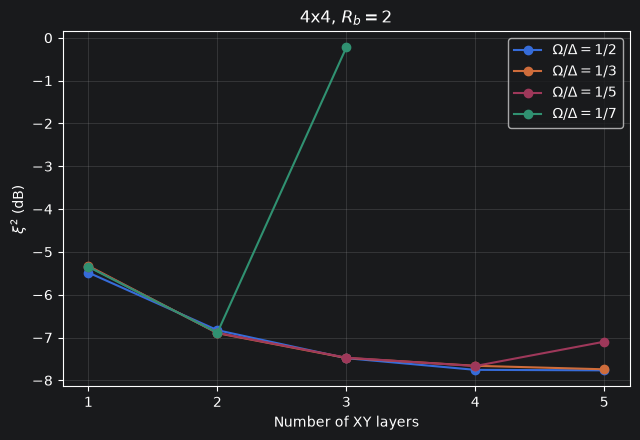

In [36]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    for rb in sorted(df_geom["Rb"].unique()):
        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_rb = df_geom[df_geom["Rb"] == rb]

        labels = (
            df_rb[
                [
                    "Omega_over_Delta",
                    "Omega_over_Delta_label",
                ]
            ]
            .drop_duplicates()
            .sort_values(
                "Omega_over_Delta",
                ascending=False,
            )
        )

        for _, ratio_row in labels.iterrows():
            ratio = ratio_row["Omega_over_Delta"]
            label = ratio_row["Omega_over_Delta_label"]

            group = df_rb[
                np.isclose(
                    df_rb["Omega_over_Delta"],
                    ratio,
                )
            ].sort_values(
                "layers"
            )

            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$\Omega/\Delta={label}$",
            )

        ax.set_xlabel("Number of XY layers")
        ax.set_ylabel(r"$\xi^2\ \mathrm{(dB)}$")
        ax.set_title(rf"{geometry}, $R_b={rb:g}$")
        ax.set_xticks(
            sorted(
                df_rb["layers"].unique()
            )
        )
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Plot 2: one figure per $\Omega/\Delta$, lines for different $R_b$


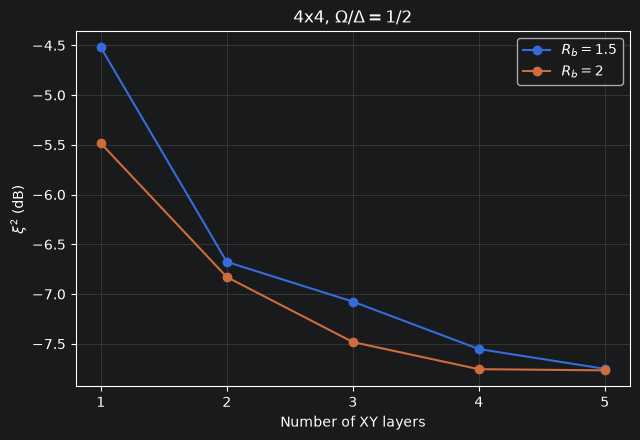

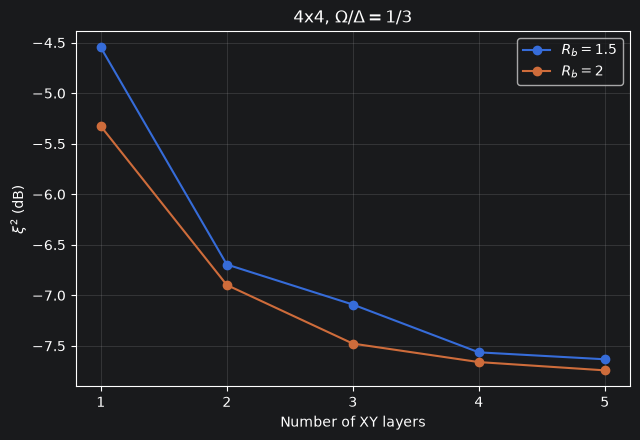

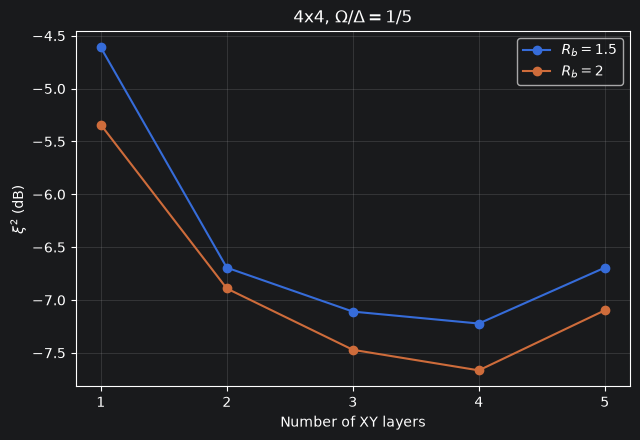

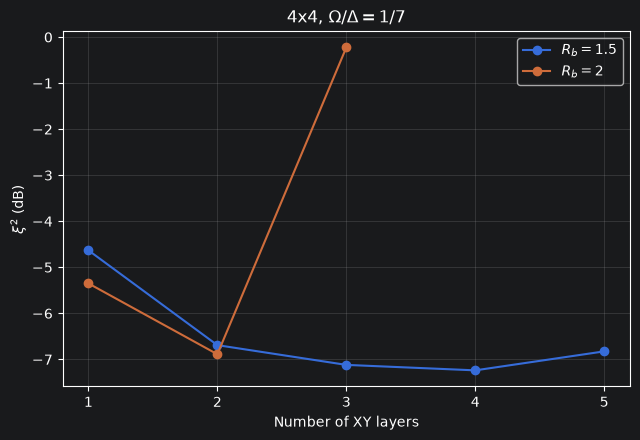

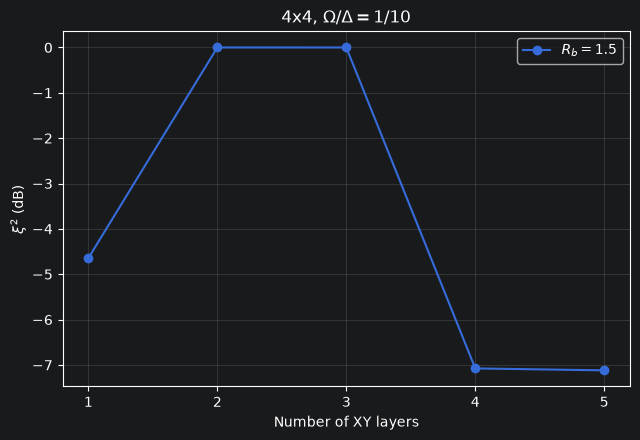

In [37]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    labels = (
        df_geom[
            [
                "Omega_over_Delta",
                "Omega_over_Delta_label",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "Omega_over_Delta",
            ascending=False,
        )
    )

    for _, row in labels.iterrows():
        ratio = row["Omega_over_Delta"]
        label = row["Omega_over_Delta_label"]

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_ratio = df_geom[
            np.isclose(
                df_geom["Omega_over_Delta"],
                ratio,
            )
        ]

        for rb, group in df_ratio.groupby("Rb"):
            group = group.sort_values("layers")

            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$R_b={rb:g}$",
            )

        ax.set_xlabel("Number of XY layers")
        ax.set_ylabel(r"$\xi^2\ \mathrm{(dB)}$")
        ax.set_title(
            rf"{geometry}, $\Omega/\Delta={label}$"
        )
        ax.set_xticks(
            sorted(
                df_ratio["layers"].unique()
            )
        )
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Inspect the optimized XY gate parameters

For an `n`-layer result, the parameter vector is interpreted as

```text
XY_echo, Rx, XY_echo, Rx, ..., XY_echo
```

`XY_echo` parameters are interaction times. `Rx` parameters are rotation
angles and are therefore kept separate below rather than being interpreted
as times.


In [38]:
def parameter_table(row):
    sequence = row["sequence"]
    parameters = row["parameters"]

    records = []

    xy_index = 0
    rx_index = 0

    for parameter_index, (gate, value) in enumerate(
        zip(sequence, parameters)
    ):

        if gate == "XY_echo":
            gate_number = xy_index + 1
            xy_index += 1
            quantity = "time"

        elif gate == "Rx":
            gate_number = rx_index + 1
            rx_index += 1
            quantity = "angle"

        else:
            gate_number = np.nan
            quantity = "parameter"

        records.append({
            "parameter_index": parameter_index,
            "gate": gate,
            "gate_number": gate_number,
            "quantity": quantity,
            "value": float(value),
        })

    return pd.DataFrame(records)


In [39]:
# Example selection
selection = df[
    (df["geometry"] == "4x4")
    & np.isclose(df["Rb"], 1.5)
    & np.isclose(df["Omega_over_Delta"], 0.5)
]

for _, row in selection.sort_values("layers").iterrows():

    print("=" * 72)

    print(
        f"layers={int(row['layers'])}, "
        f"xi={row['xi']:.8g}, "
        f"xi^2={dB(row['xi'] ** 2):.3f} dB"
    )

    print(
        "single_pulse_min_time=",
        row["single_pulse_min_time"],
    )

    display(
        parameter_table(row)
    )


layers=1, xi=0.59421011, xi^2=-4.521 dB
single_pulse_min_time= 239.85450306663827


,parameter_index,gate,gate_number,quantity,value
0,0,XY_echo,1,time,239.854866


layers=2, xi=0.46362389, xi^2=-6.677 dB
single_pulse_min_time= 239.85450306663827


,parameter_index,gate,gate_number,quantity,value
0,0,XY_echo,1,time,159.128714
1,1,Rx,1,angle,0.483316
2,2,XY_echo,2,time,431.467198


layers=3, xi=0.4428049, xi^2=-7.076 dB
single_pulse_min_time= 239.85450306663827


,parameter_index,gate,gate_number,quantity,value
0,0,XY_echo,1,time,106.338182
1,1,Rx,1,angle,0.573821
2,2,XY_echo,2,time,310.434134
3,3,Rx,2,angle,0.174961
4,4,XY_echo,3,time,303.850904


layers=4, xi=0.41915467, xi^2=-7.553 dB
single_pulse_min_time= 239.85450306663827


,parameter_index,gate,gate_number,quantity,value
0,0,XY_echo,1,time,118.888745
1,1,Rx,1,angle,-2.574815
2,2,XY_echo,2,time,319.548626
3,3,Rx,2,angle,-2.889079
4,4,XY_echo,3,time,461.382132
5,5,Rx,3,angle,0.060435
6,6,XY_echo,4,time,479.709006


layers=5, xi=0.40964306, xi^2=-7.752 dB
single_pulse_min_time= 239.85450306663827


,parameter_index,gate,gate_number,quantity,value
0,0,XY_echo,1,time,91.209479
1,1,Rx,1,angle,0.627198
2,2,XY_echo,2,time,240.584872
3,3,Rx,2,angle,-2.930653
4,4,XY_echo,3,time,287.931916
5,5,Rx,3,angle,0.166026
6,6,XY_echo,4,time,479.709006
7,7,Rx,4,angle,0.027695
8,8,XY_echo,5,time,414.365201


## Optional: save the collected XY-results table

The gate sequence and optimized parameter arrays are converted to ordinary
Python lists/strings before writing the CSV.


In [40]:
df_export = df.copy()

df_export["parameters"] = (
    df_export["parameters"]
    .apply(lambda x: x.tolist())
)

df_export["sequence"] = (
    df_export["sequence"]
    .apply(lambda x: ",".join(x))
)

output_file = (
    RESULTS_DIR
    / "optimization_summary_XY.csv"
)

df_export.to_csv(
    output_file,
    index=False,
)

print("Saved:", output_file)


Saved: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_XY/optimization_summary_XY.csv
